In [191]:
import pandas as pd
import time 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [192]:
data_path = "gaming_addiction.csv"

df = pd.read_csv(data_path)

df.head()


,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,in_game_purchases,monthly_spending_usd,lootbox_openings,subscription_status,stress_score,loneliness_score,dopamine_dependency_index,self_control_score,impulsiveness_score,anxiety_level,depression_indicator,emotional_stability,sleep_hours,exercise_frequency_per_week,caffeine_intake_cups_day,social_interaction_hours,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,Gold,3.5,4,1.0,4.9,6.5,0.67,0,0,0,38.67,10,NaN,8.2,8.8,2.7,7.0,5.1,9.9,8.5,3.7,6.3,2,0,2.7,In a relationship,4.0,4,0.0,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,Bronze,10.9,14,3.2,14.7,15.9,0.44,2,0,7,47.35,18,Premium,7.8,5.6,8.2,6.5,3.5,6.2,4.1,3.0,6.1,0,2,3.5,In a relationship,4.0,4,16.7,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,Master,8.6,7,2.4,11.6,13.1,0.32,0,1,3,37.80,4,Ultimate,8.4,4.1,5.0,4.2,6.1,7.7,6.7,3.3,6.1,1,3,2.0,Prefer not to say,4.0,6,8.5,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,Bronze,5.9,5,1.1,13.6,8.2,0.23,7,7,9,74.51,15,NaN,6.0,4.5,6.0,5.8,3.6,5.9,4.5,6.5,6.7,4,5,0.6,Married,4.0,3,8.7,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,Bronze,7.4,8,3.2,6.3,14.2,0.57,4,2,5,25.32,0,Premium,8.0,4.2,6.2,6.5,5.0,8.4,3.3,5.5,7.6,1,0,1.2,Single,2.6,3,21.9,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [193]:
# Dropping user_id we dont use it
df = df.drop(['user_id'], axis=1)

In [194]:

# print(df.columns.to_list())
# print(df.dtypes)
# print(df.shape)

print("Reading data null : ", df.isnull().sum())




Reading data null :  age                             0
gender                          0
country                         0
occupation                      0
income_level                    0
years_gaming                    0
preferred_genre                 0
platform                        0
device_type                     0
rank_tier                       0
daily_playtime_hours            0
weekly_play_sessions            0
late_night_sessions_hours       0
weekend_playtime_hours          0
consecutive_hours_max           0
multiplayer_ratio               0
toxic_chat_reports              0
rage_quit_frequency             0
in_game_purchases               0
monthly_spending_usd            0
lootbox_openings                0
subscription_status            82
stress_score                    0
loneliness_score                0
dopamine_dependency_index       0
self_control_score              0
impulsiveness_score             0
anxiety_level                   0
depression_indicator       

subscription_status         82
depression_indicator        11
gpa_or_performance_score    10
addiction_severity          16
dtype: int64


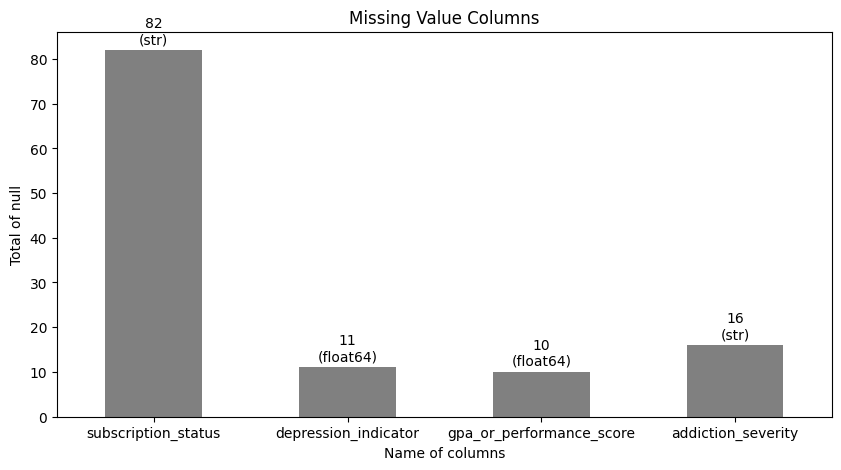

In [195]:
# Searching for null fields

missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,5))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=0)
plt.show()

In [196]:
# Fixing missing value with SimpleImputer for numerical and catergory

dfe = df.copy()

# Numerical -> Median
num_imputer = SimpleImputer(strategy='median')
num_cols = ['depression_indicator', 'gpa_or_performance_score']
dfe[num_cols] = num_imputer.fit_transform(dfe[num_cols])

# Catergorial -> Modus 
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = ['subscription_status', 'addiction_severity']
dfe[cat_cols] = cat_imputer.fit_transform(dfe[cat_cols])

print("Updating missing value : ", dfe.isnull().sum().max())



Updating missing value :  0


In [197]:
# Preprocessing read the ob

print(dfe.select_dtypes(include=['object', 'str']))


print("Behavioral_cluster : ", dfe['behavioral_cluster'].unique())


     gender      country  ...   behavioral_cluster addiction_severity
0      Male        India  ...       Casual Enjoyer               Mild
1      Male        India  ...     Streamer/Creator           Moderate
2      Male       Brazil  ...     Streamer/Creator           Moderate
3      Male  South Korea  ...     Toxic Competitor               Mild
4    Female        India  ...  Competitive Grinder           Moderate
..      ...          ...  ...                  ...                ...
245  Female        Japan  ...     Streamer/Creator           Moderate
246    Male        India  ...         Social Gamer               Mild
247    Male          USA  ...        Escape Seeker               Mild
248    Male  South Korea  ...         Social Gamer               Mild
249    Male          USA  ...         Social Gamer           Moderate

[250 rows x 12 columns]
Behavioral_cluster :  <StringArray>
[     'Casual Enjoyer',    'Streamer/Creator',    'Toxic Competitor',
 'Competitive Grinder',      

In [198]:
# Manual encoding using map 

cols = ['addiction_severity', 'income_level', 'subscription_status', 'rank_tier']

for i, col_name in enumerate(cols):
    # 3. Used the correct variable '{col_name}' and added a unique count method
    unique_count = df[col_name].unique()
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

dfe['income_level'] = dfe['income_level'].map({"Low" : 0, "Lower-Middle" : 1, "Middle" : 2, "Upper-Middle" : 3, "High" : 4})

dfe['addiction_severity'] = dfe['addiction_severity'].map({"Mild" : 0, "Moderate" : 1, "Severe" : 2})

dfe['subscription_status'] = dfe['subscription_status'].map({"Basic" : 0, "Premium" : 1, "Ultimate" : 2})

dfe['rank_tier'] = dfe['rank_tier'].map({"Unranked" : 0, "Bronze" : 1, "Silver" : 2, "Gold" : 3, "Platinum" : 4, "Diamond" : 5, "Master" : 6, "Grandmaster" : 7})

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_cols = ['gender', 'country', 'occupation', 'preferred_genre', 'platform', 'device_type', 'relationship_status', 'behavioral_cluster']

dfe = pd.get_dummies(dfe, columns=ohe_cols)

print(dfe.select_dtypes(include=['object', 'str']).columns.to_list)


Index 0: 'addiction_severity' has <StringArray>
['Mild', 'Moderate', nan, 'Severe']
Length: 4, dtype: str unique values
Index 1: 'income_level' has <StringArray>
['Middle', 'Lower-Middle', 'Upper-Middle', 'High', 'Low']
Length: 5, dtype: str unique values
Index 2: 'subscription_status' has <StringArray>
[nan, 'Premium', 'Ultimate', 'Basic']
Length: 4, dtype: str unique values
Index 3: 'rank_tier' has <StringArray>
[       'Gold',      'Bronze',      'Master',      'Silver',    'Unranked',
     'Diamond', 'Grandmaster',    'Platinum']
Length: 8, dtype: str unique values
<bound method IndexOpsMixin.tolist of Index([], dtype='str')>


In [199]:
dfe.dtypes

age                                         int64
income_level                                int64
years_gaming                                int64
rank_tier                                   int64
daily_playtime_hours                      float64
                                           ...   
behavioral_cluster_Competitive Grinder       bool
behavioral_cluster_Escape Seeker             bool
behavioral_cluster_Social Gamer              bool
behavioral_cluster_Streamer/Creator          bool
behavioral_cluster_Toxic Competitor          bool
Length: 97, dtype: object

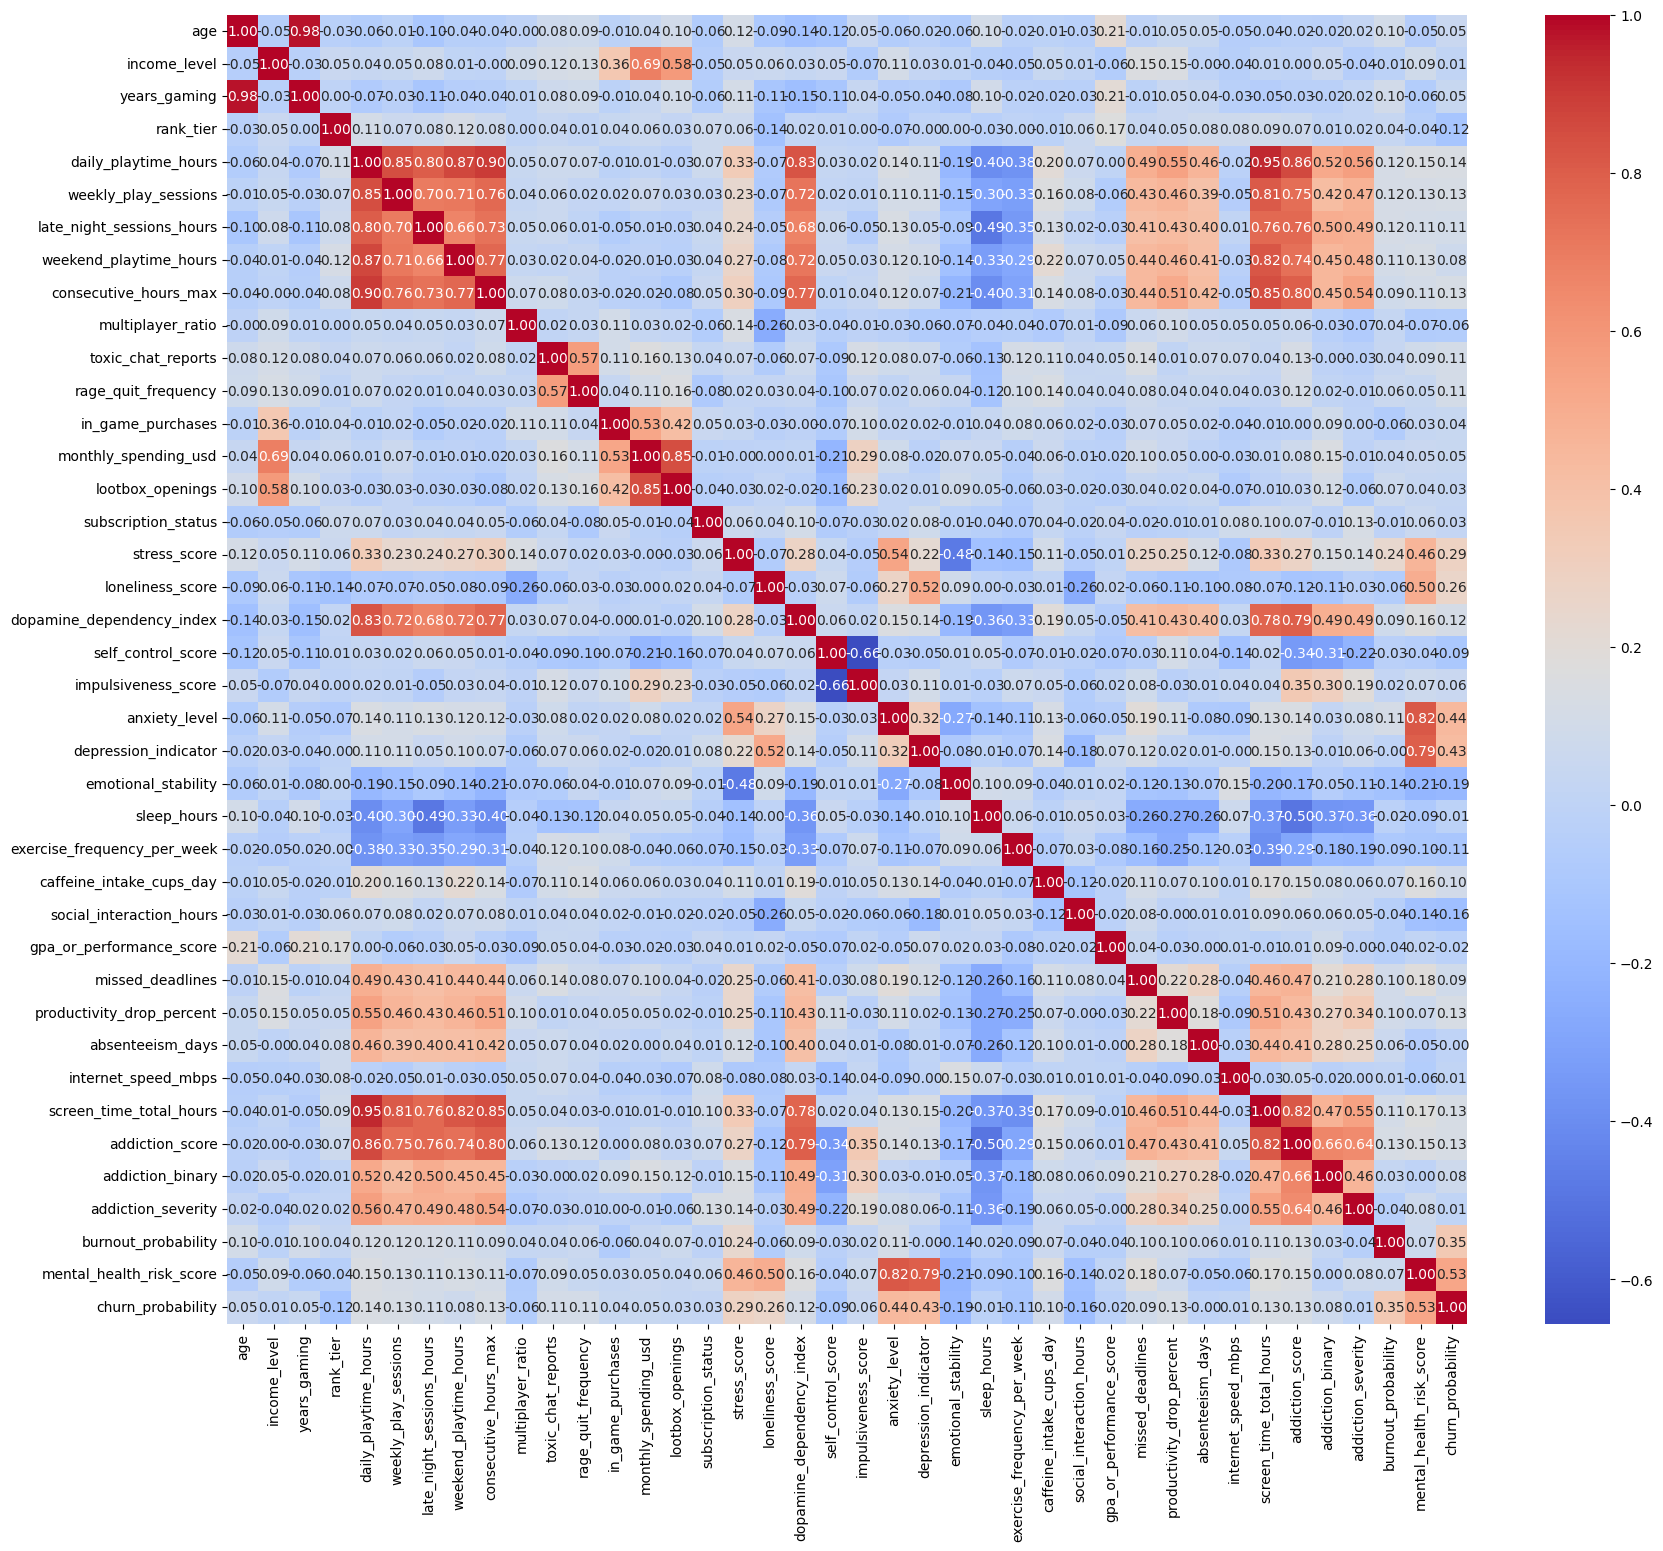

In [200]:
# Seaborn heatmap 

plt.figure(figsize=(20,17))

corr = dfe.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

In [202]:
# Getting feature using the highest corelation

corr_matrix = dfe.corr().abs()

corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False))

print("Head of corr : \n", corr_pairs.head(15))

Head of corr : 
 age                       years_gaming                 0.979611
daily_playtime_hours      screen_time_total_hours      0.945771
gpa_or_performance_score  occupation_Student           0.915510
daily_playtime_hours      consecutive_hours_max        0.900978
                          weekend_playtime_hours       0.865625
                          addiction_score              0.861188
monthly_spending_usd      lootbox_openings             0.847545
daily_playtime_hours      weekly_play_sessions         0.847174
consecutive_hours_max     screen_time_total_hours      0.846300
daily_playtime_hours      dopamine_dependency_index    0.827996
weekend_playtime_hours    screen_time_total_hours      0.822905
anxiety_level             mental_health_risk_score     0.816669
screen_time_total_hours   addiction_score              0.815875
weekly_play_sessions      screen_time_total_hours      0.808181
daily_playtime_hours      late_night_sessions_hours    0.800191
dtype: float64


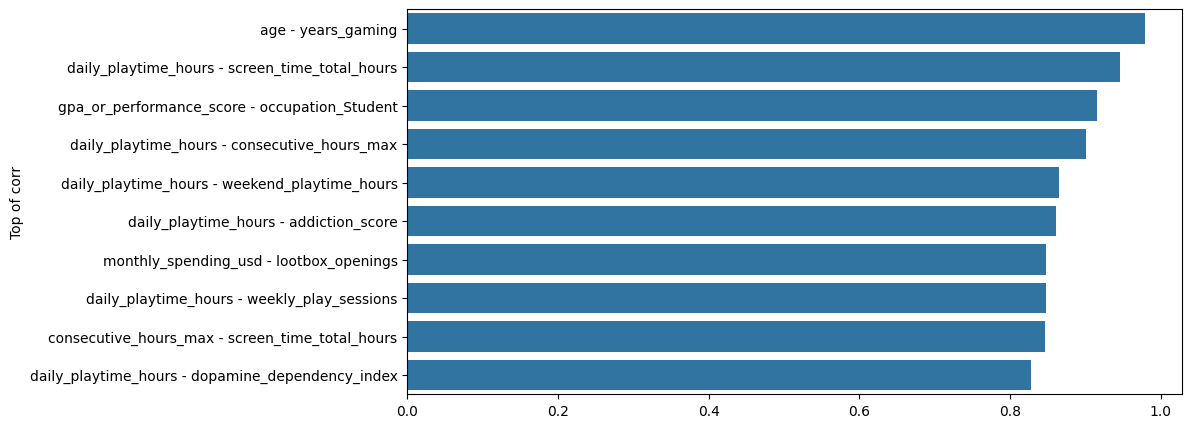

In [230]:
# Feature comparison visual data

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


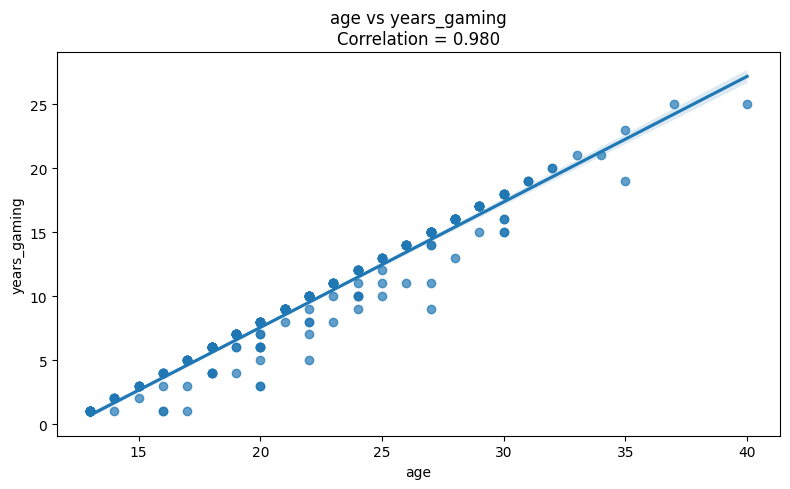

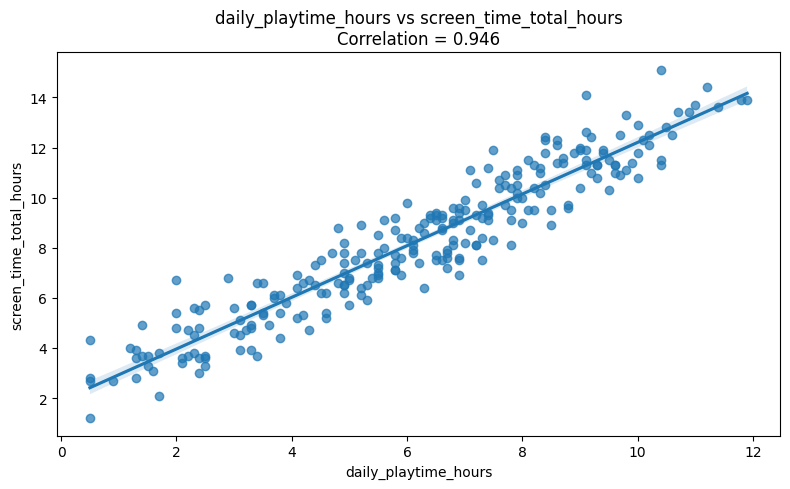

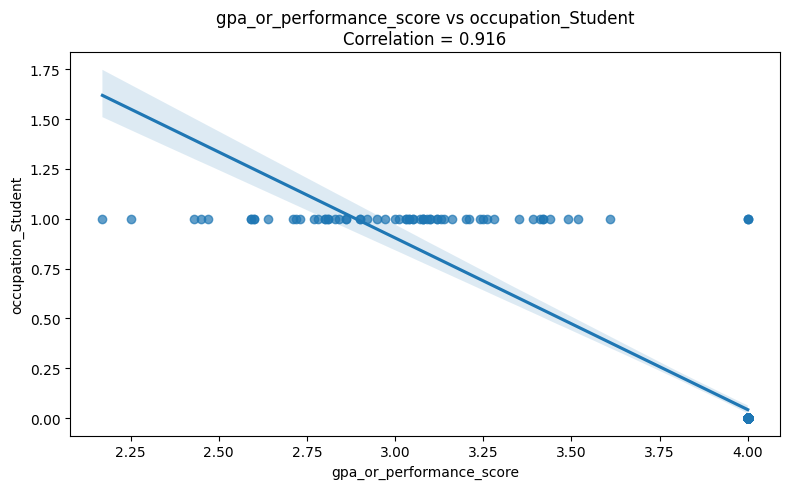

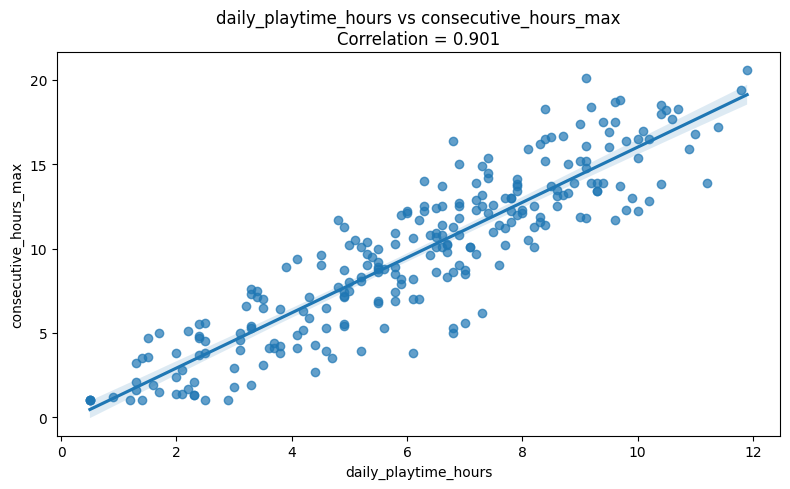

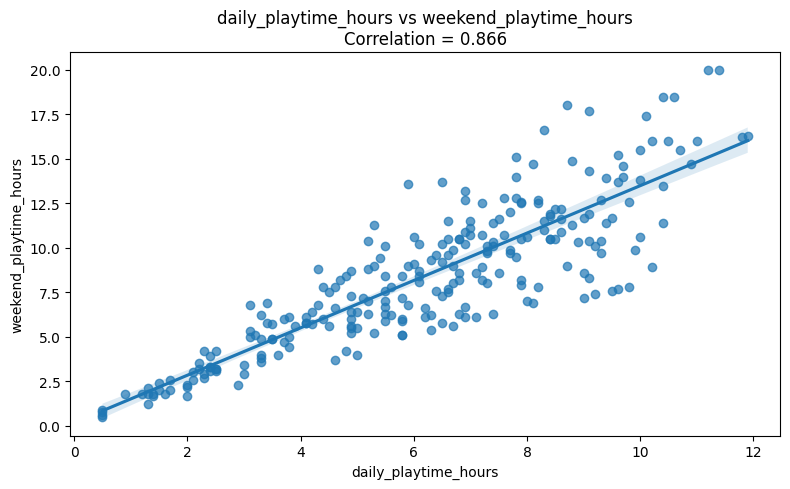

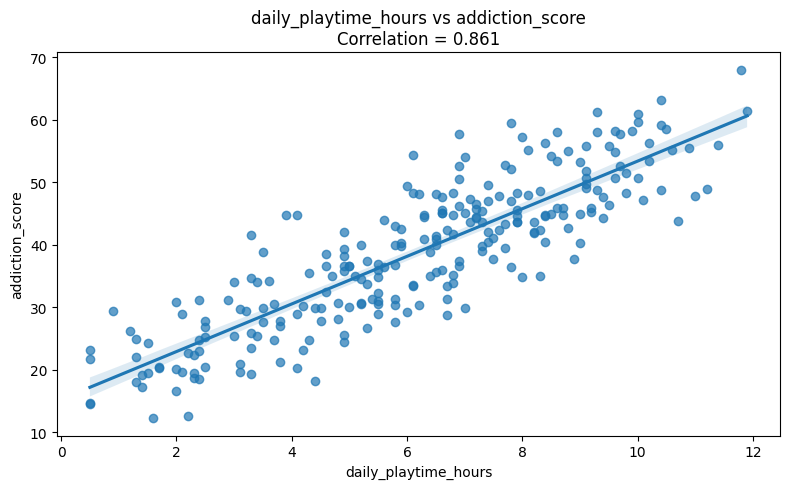

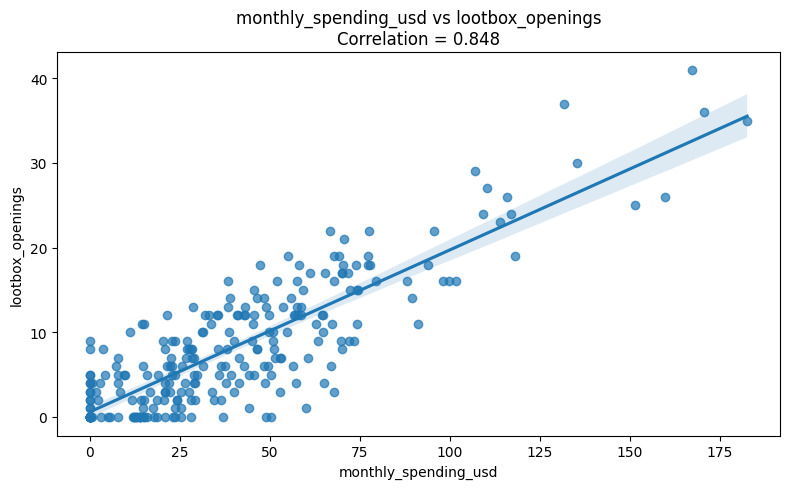

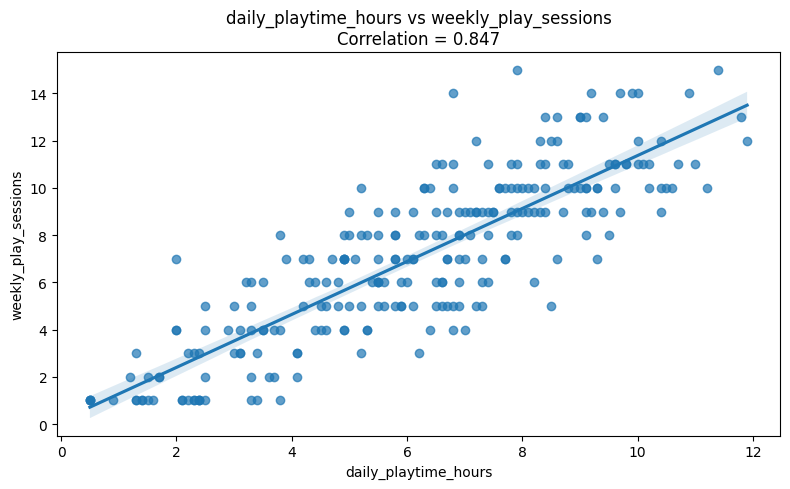

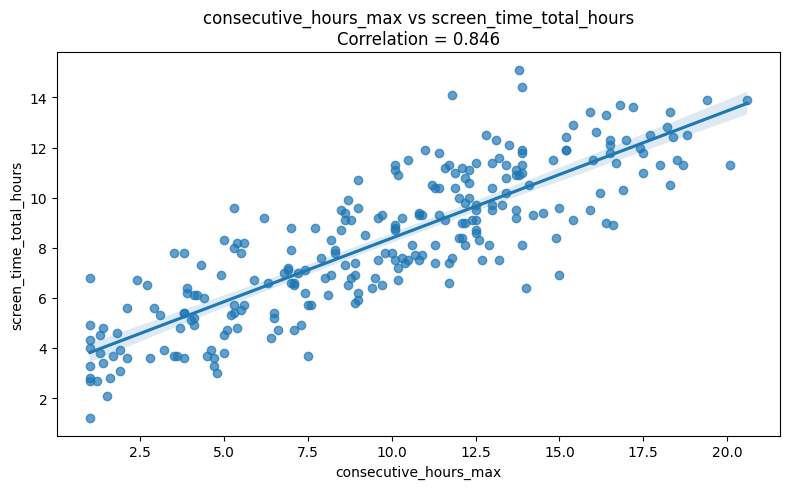

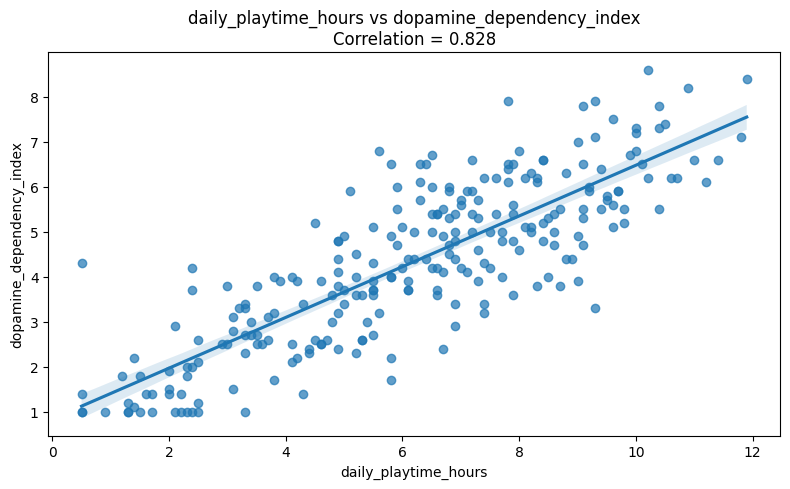

In [ ]:
top_n = 10

for (feature1, feature2), corr_value in corr_pairs.head(top_n).items():

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=dfe,
        x=feature1,
        y=feature2,
        scatter_kws={"alpha": 0.7}
    )

    plt.title(import math
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 9

pairs = corr_pairs.head(top_n)

ncols = 3
nrows = math.ceil(top_n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows)
)

axes = axes.flatten()

for idx, ((f1, f2), corr) in enumerate(pairs.items()):

    sns.regplot(
        data=dfe,
        x=f1,
        y=f2,
        ax=axes[idx],
        scatter_kws={"alpha": 0.5, "s": 25},
        line_kws={"linewidth": 2}
    )

    axes[idx].set_title(
        f"r = {corr:.3f}",
        fontsize=11
    )

    axes[idx].tick_params(
        axis='x',
        rotation=45,
        labelsize=8
    )

    axes[idx].tick_params(
        axis='y',
        labelsize=8
    )

# Hapus subplot kosong
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Top Correlated Feature Pairs",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()
        f"{feature1} vs {feature2}\nCorrelation = {corr_value:.3f}"
    )

    plt.tight_layout()
    plt.show()